# News-Driven LSTM Next-Day Predictive Trading Strategy for S-REITs

This notebook implements a sentiment-enhanced LSTM model to predict next-day prices for 9 SGX-listed S-REITs, then simulates a trading strategy benchmarked against the iEdge S-REIT Leaders Index (SRT.SI).

## Pipeline Overview
1. Fetch 5 years of price data (2021–present) via yfinance
2. Load FinBERT sentiment scores from CSV files
3. Merge sentiment with price data
4. Train LSTM model (80/20 train-test split, 20% validation, early stopping)
5. Evaluate with MAE, MSE, RMSE, R²
6. Simulate News-Driven Next-Day Predictive Trading Strategy (SGD 100,000 per REIT)
7. Benchmark against SRT.SI

## Setup
```
pip install yfinance tensorflow scikit-learn pandas numpy matplotlib
```

**Folder structure:**
```
your_project/
├── this_notebook.ipynb
├── sentiment_data/
│   ├── P40U.csv
│   ├── J69U.csv
│   ├── ODBU.csv
│   ├── MXNU.csv
│   ├── K71U.csv
│   ├── UD1U.csv
│   ├── C38U.csv
│   ├── BUOU.csv
│   └── TS0U.csv
└── results/        (created automatically)
```

In [1]:
pip install yfinance tensorflow scikit-learn pandas numpy matplotlib seaborn

  Preparing metadata (setup.py) ... done
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 6.0 MB/s eta 0:00:00m eta 0:00:010:00:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 5.7 MB/s eta 0:00:005.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 5.7 MB/s eta 0:00:006.0 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 5.7 MB/s eta 0:00:00m eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 6.5 MB/s eta 0:00:00 MB/s eta 0:00:01:01
Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Created wheel for multitasking: filename=multitasking-0.0.12-py3-none-any.whl size=15548 sha256=61b071ff391f63f3ca8bed45881194fbc7d9d7927aafadf54d84c136754fc46d
  Stored in directory: /home/f34/.cache/pip/wheels/cc/bd/6f/664d62c99327abeef7d86489e6631cbf45

In [2]:
# IMPORTS & CONFIGURATION

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import yfinance as yf
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# ── CONFIGURATION ──
REIT_UNIVERSE = {
    'P40U': {'name': 'Starhill Global REIT',                   'sector': 'Retail',      'yahoo': 'P40U.SI'},
    'J69U': {'name': 'Frasers Centrepoint Trust',              'sector': 'Retail',      'yahoo': 'J69U.SI'},
    'ODBU': {'name': 'United Hampshire US REIT',               'sector': 'Retail',      'yahoo': 'ODBU.SI'},
    'MXNU': {'name': 'Elite UK REIT',                          'sector': 'Office',      'yahoo': 'MXNU.SI'},
    'K71U': {'name': 'Keppel REIT',                            'sector': 'Office',      'yahoo': 'K71U.SI'},
    'UD1U': {'name': 'IREIT Global',                           'sector': 'Office',      'yahoo': 'UD1U.SI'},
    'C38U': {'name': 'CapitaLand Integrated Commercial Trust', 'sector': 'Diversified', 'yahoo': 'C38U.SI'},
    'BUOU': {'name': 'Frasers Logistics & Commercial Trust',   'sector': 'Diversified', 'yahoo': 'BUOU.SI'},
    'TS0U': {'name': 'OUE REIT',                               'sector': 'Diversified', 'yahoo': 'TS0U.SI'},
}
TICKERS = list(REIT_UNIVERSE.keys())

SENTIMENT_DIR     = './sentiment_data'   # Folder containing {TICKER}.csv files
RESULTS_DIR       = './results'          # Output folder
LOOKBACK          = 60                   # LSTM input window (60 trading days)
INITIAL_CAPITAL   = 100_000             # SGD per REIT
STOP_LOSS         = 0.20                # 20% stop loss
PERCENT_OF_EQUITY = 0.80               # Trade with 80% of equity
TRADE_START       = '2023-03-27'
TRADE_END         = '2026-03-27'

# TA gate parameters (Script A: EMA 20/50 | Script B: RSI 14)
EMA_FAST   = 20
EMA_SLOW   = 50
RSI_PERIOD = 14

os.makedirs(RESULTS_DIR, exist_ok=True)

print(f'TensorFlow {tf.__version__}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')
print(f'REITs: {TICKERS}')
print(f'Sentiment dir: {os.path.abspath(SENTIMENT_DIR)}')
print(f'Results dir:   {os.path.abspath(RESULTS_DIR)}')
print(f'TA gate: EMA({EMA_FAST}/{EMA_SLOW}) + RSI({RSI_PERIOD})')


I0000 00:00:1775617699.034230   14103 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775617699.035457   14103 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775617699.126777   14103 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775617701.323973   14103 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

TensorFlow 2.21.0
GPU: []
REITs: ['P40U', 'J69U', 'ODBU', 'MXNU', 'K71U', 'UD1U', 'C38U', 'BUOU', 'TS0U']
Sentiment dir: /home/f34/Downloads/ML (LSTM)/sentiment_data
Results dir:   /home/f34/Downloads/ML (LSTM)/results
TA gate: EMA(20/50) + RSI(14)


E0000 00:00:1775617701.743639   14103 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775617701.744316   14662 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775617701.778639   14103 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:

# CORE FUNCTIONS

# Sentiment loading

def fetch_price_data(ticker_info, start='2021-01-01'):
    yahoo = ticker_info['yahoo']
    data = yf.download(yahoo, start=start, auto_adjust=True, progress=False)
    if data.empty:
        raise ValueError(f'No data for {yahoo}')
    data.columns = [c.lower() if isinstance(c, str) else c[0].lower() for c in data.columns]
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)
    if isinstance(data.index, pd.MultiIndex):
        data.index = data.index.get_level_values(0)
    data.index = pd.to_datetime(data.index)
    data = data[['close']].dropna()
    data.columns = ['GT']
    return data


# Sentiment loading

def load_sentiment(ticker, sentiment_dir=SENTIMENT_DIR):
    path = os.path.join(sentiment_dir, f'{ticker}.csv')
    if not os.path.exists(path):
        print(f'  No sentiment file for {ticker}')
        return pd.DataFrame()
    df = pd.read_csv(path)
    df['pub_date'] = pd.to_datetime(df['pub_date'], format='mixed', utc=True)
    df['date'] = df['pub_date'].dt.tz_localize(None).dt.normalize()
    daily = df.groupby('date').agg(
        sentiment_score=('weighted_score', 'mean'),
        positive_ratio=('sentiment', lambda x: (x == 'positive').mean()),
        negative_ratio=('sentiment', lambda x: (x == 'negative').mean()),
        article_count=('weighted_score', 'count'),
        mean_confidence=('confidence', 'mean'),
    )
    return daily


def merge_sentiment_with_price(price_df, sentiment_df):
    merged = price_df.copy()
    if not sentiment_df.empty:
        sent_aligned = sentiment_df.reindex(merged.index)
        sent_aligned['sentiment_score']   = sent_aligned['sentiment_score'].ffill().fillna(0)
        sent_aligned['positive_ratio']    = sent_aligned['positive_ratio'].ffill().fillna(0.5)
        sent_aligned['negative_ratio']    = sent_aligned['negative_ratio'].ffill().fillna(0.5)
        sent_aligned['article_count']     = sent_aligned['article_count'].fillna(0)
        sent_aligned['mean_confidence']   = sent_aligned['mean_confidence'].ffill().fillna(0.5)
        sent_aligned['sentiment_numeric'] = np.where(
            sent_aligned['sentiment_score'] > 0.05, 1,
            np.where(sent_aligned['sentiment_score'] < -0.05, -1, 0)
        )
        for col in sent_aligned.columns:
            merged[col] = sent_aligned[col]
    else:
        merged['sentiment_score']   = 0
        merged['positive_ratio']    = 0.5
        merged['negative_ratio']    = 0.5
        merged['article_count']     = 0
        merged['mean_confidence']   = 0.5
        merged['sentiment_numeric'] = 0
    return merged


# LSTM model 

def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(50, return_sequences=True, input_shape=input_shape),
        LSTM(50, return_sequences=False),
        Dense(25, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model


def create_sequences(data, lookback=LOOKBACK):
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i])
        y.append(data[i, 0])
    return np.array(X), np.array(y)


def evaluate_model(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}


# TA gate (EMA 20/50 & RSI) 

def compute_ema(series, span):
    return series.ewm(span=span, adjust=False).mean()


def compute_rsi(series, period=RSI_PERIOD):
    delta = series.diff()
    gain  = delta.clip(lower=0).ewm(alpha=1/period, adjust=False).mean()
    loss  = (-delta.clip(upper=0)).ewm(alpha=1/period, adjust=False).mean()
    rs    = gain / loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def compute_ta_gate(close_series, ema_fast=EMA_FAST, ema_slow=EMA_SLOW, rsi_period=RSI_PERIOD):
    """
    Returns daily Series aligned to close_series.index:
      +1  -> EMA20 > EMA50 AND RSI > 50  (bullish: both signals agree)
      -1  -> EMA20 < EMA50 AND RSI < 50  (bearish: both signals agree)
       0  -> signals conflict (stay flat)
    Mirrors Script A (EMA 20/50) and Script B (RSI 14) from the TA module.
    """
    ema_f   = compute_ema(close_series, ema_fast)
    ema_s   = compute_ema(close_series, ema_slow)
    rsi     = compute_rsi(close_series, rsi_period)
    ema_dir = np.sign(ema_f - ema_s).astype(int)
    rsi_dir = np.where(rsi > 50, 1, -1)
    gate    = np.where(ema_dir == rsi_dir, ema_dir, 0)
    return pd.Series(gate, index=close_series.index, dtype=float)


# LSTM + sentiment + TA gate 

def run_trading_strategy(test_df, close_series,
                         initial_capital=INITIAL_CAPITAL,
                         stop_loss=STOP_LOSS,
                         pct_equity=PERCENT_OF_EQUITY):
    """
    Entry logic (all three must agree):
      Long  : predicted_next > current_GT  AND  sentiment >= 0  AND  TA gate == +1
      Short : predicted_next < current_GT  AND  sentiment <= 0  AND  TA gate == -1

    Exit logic (any one condition triggers exit):
      Long  : prediction reverses  OR  sentiment turns negative  OR  stop-loss hit
      Short : prediction reverses  OR  sentiment turns positive  OR  stop-loss hit

    close_series : full price history (needs pre-test data for EMA/RSI warmup)
    """
    # Compute TA gate over full price history, slice to test window
    ta_full = compute_ta_gate(close_series)
    ta_gate = ta_full.reindex(test_df.index).ffill().fillna(0)

    capital     = initial_capital
    equity      = initial_capital
    position    = None   # 'long', 'short', or None
    entry_price = 0
    trade_log   = []

    for i in range(1, len(test_df) - 1):
        current_price  = test_df['GT'].iloc[i]
        predicted_next = test_df['Predict'].iloc[i + 1] if i + 1 < len(test_df) else current_price
        sentiment      = test_df['sentiment_numeric'].iloc[i] if 'sentiment_numeric' in test_df.columns else 0
        ta_signal      = ta_gate.iloc[i]
        date           = test_df.index[i]

        # EXIT CONDITIONS
        if position == 'long':
            if (predicted_next < current_price or
                    sentiment == -1 or
                    current_price <= entry_price * (1 - stop_loss)):
                profit = (current_price - entry_price) * (capital * pct_equity / entry_price)
                equity += profit
                trade_log.append({'Date': date, 'Action': 'Exit Long',
                                  'Price': current_price, 'Profit': profit,
                                  'TA Gate': ta_signal, 'Equity': equity})
                position = None

        elif position == 'short':
            if (predicted_next > current_price or
                    sentiment == 1 or
                    current_price >= entry_price * (1 + stop_loss)):
                profit = (entry_price - current_price) * (capital * pct_equity / entry_price)
                equity += profit
                trade_log.append({'Date': date, 'Action': 'Exit Short',
                                  'Price': current_price, 'Profit': profit,
                                  'TA Gate': ta_signal, 'Equity': equity})
                position = None

        # ENTRY CONDITIONS (LSTM + sentiment + TA gate must all agree)
        if position is None:
            if (predicted_next > current_price and
                    sentiment in [1, 0] and
                    ta_signal == 1):
                position    = 'long'
                entry_price = current_price
                trade_log.append({'Date': date, 'Action': 'Enter Long',
                                  'Price': current_price, 'Profit': 0,
                                  'TA Gate': ta_signal, 'Equity': equity})

            elif (predicted_next < current_price and
                      sentiment in [-1, 0] and
                      ta_signal == -1):
                position    = 'short'
                entry_price = current_price
                trade_log.append({'Date': date, 'Action': 'Enter Short',
                                  'Price': current_price, 'Profit': 0,
                                  'TA Gate': ta_signal, 'Equity': equity})

    # Force close at period end
    if position is not None:
        final_price = test_df['GT'].iloc[-1]
        profit = ((final_price - entry_price) if position == 'long'
                  else (entry_price - final_price)) * (capital * pct_equity / entry_price)
        equity += profit
        trade_log.append({'Date': test_df.index[-1],
                          'Action': f'Force Exit {position.title()}',
                          'Price': final_price, 'Profit': profit,
                          'TA Gate': ta_gate.iloc[-1], 'Equity': equity})

    trade_df       = pd.DataFrame(trade_log)
    net_profit     = equity - initial_capital
    net_return     = (net_profit / initial_capital) * 100
    ta_conflict_pct = (ta_gate == 0).mean() * 100

    return {
        'net_profit':       net_profit,
        'net_return':       net_return,
        'final_equity':     equity,
        'n_trades':         len([t for t in trade_log if 'Exit' in t['Action']]),
        'trade_log':        trade_df,
        'ta_conflict_pct':  ta_conflict_pct,
    }


#  Full per-REIT pipeline 

def run_full_pipeline(ticker, ticker_info):
    print(f'\n{"="*60}')
    print(f'  {ticker_info["name"]} ({ticker})')
    print(f'  Sector: {ticker_info["sector"]}')
    print(f'{"="*60}')

    # 1. Price data (full history for TA warmup)
    print('\n[1/7] Fetching price data...')
    price_df     = fetch_price_data(ticker_info, start='2021-01-01')
    close_series = price_df['GT']
    print(f'  {len(price_df)} rows ({price_df.index[0].date()} to {price_df.index[-1].date()})')

    # 2. Sentiment
    print('[2/7] Loading sentiment data...')
    sentiment_df = load_sentiment(ticker)
    if not sentiment_df.empty:
        print(f'  {len(sentiment_df)} daily sentiment records')
    else:
        print('  No sentiment data - using neutral defaults')

    # 3. Merge
    print('[3/7] Merging sentiment with price data...')
    merged = merge_sentiment_with_price(price_df, sentiment_df)
    feature_cols = ['GT', 'sentiment_score', 'positive_ratio',
                    'negative_ratio', 'article_count', 'mean_confidence']
    data_array = merged[feature_cols].values

    # 4. Scale and split
    print('[4/7] Scaling and creating sequences...')
    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(data_array)
    X, y   = create_sequences(scaled, LOOKBACK)
    split  = int(len(X) * 0.8)
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]
    print(f'  Train: {len(X_train)} | Test: {len(X_test)} | Features: {X.shape[2]}')

    # 5. Train LSTM
    print('[5/7] Training LSTM model...')
    model    = build_lstm_model((X_train.shape[1], X_train.shape[2]))
    callback = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    history  = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=200,
        batch_size=32,
        callbacks=[callback],
        verbose=0
    )
    print(f'  Trained for {len(history.history["loss"])} epochs')

    # 6. Predict and inverse-transform
    print('[6/7] Evaluating model...')
    y_pred_scaled = model.predict(X_test, verbose=0)

    y_test_full = np.zeros((len(y_test), len(feature_cols)))
    y_test_full[:, 0] = y_test
    y_test_actual = scaler.inverse_transform(y_test_full)[:, 0]

    y_pred_full = np.zeros((len(y_pred_scaled), len(feature_cols)))
    y_pred_full[:, 0] = y_pred_scaled.flatten()
    y_pred_actual = scaler.inverse_transform(y_pred_full)[:, 0]

    metrics = evaluate_model(y_test_actual, y_pred_actual)
    print(f'  MAE:  {metrics["MAE"]:.6f}')
    print(f'  MSE:  {metrics["MSE"]:.6f}')
    print(f'  RMSE: {metrics["RMSE"]:.6f}')
    print(f'  R2:   {metrics["R2"]:.6f}')

    # Build test DataFrame
    test_dates = merged.index[LOOKBACK + split: LOOKBACK + split + len(y_test)]
    test_df    = pd.DataFrame({'GT': y_test_actual, 'Predict': y_pred_actual},
                              index=test_dates)
    if 'sentiment_numeric' in merged.columns:
        test_df['sentiment_numeric'] = (merged['sentiment_numeric']
                                        .reindex(test_dates).fillna(0).values)
    else:
        test_df['sentiment_numeric'] = 0

    # 7. Trading simulation
    print('[7/7] Simulating trading strategy (LSTM + sentiment + TA gate)...')
    trade_mask = (test_df.index >= TRADE_START) & (test_df.index <= TRADE_END)
    trade_df   = test_df[trade_mask].copy()
    if len(trade_df) < 10:
        print(f'  WARNING: only {len(trade_df)} days in benchmark window - using full test set.')
        trade_df = test_df.copy()

    strategy = run_trading_strategy(trade_df, close_series)
    print(f'  Net Profit:    SGD {strategy["net_profit"]:,.2f}')
    print(f'  Net Return:    {strategy["net_return"]:.2f}%')
    print(f'  Trades:        {strategy["n_trades"]}')
    print(f'  TA flat days:  {strategy["ta_conflict_pct"]:.1f}% (EMA/RSI conflicted)')

    # Plots
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_df.index, test_df['GT'],      label='Ground Truth', color='blue',   lw=1.5)
    ax.plot(test_df.index, test_df['Predict'], label='Predicted',    color='orange', lw=1.5)
    ax.set_title(f'{ticker_info["name"]} ({ticker}) - Predicted vs Ground Truth',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Price (SGD)')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/{ticker}_prediction.png', dpi=150, bbox_inches='tight')
    plt.show()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(history.history['loss'],     label='Training Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')
    ax.set_title(f'{ticker} - Training vs Validation Loss', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/{ticker}_training_loss.png', dpi=150, bbox_inches='tight')
    plt.show()

    result = {
        'ticker':   ticker,
        'name':     ticker_info['name'],
        'sector':   ticker_info['sector'],
        'metrics':  metrics,
        'strategy': strategy,
        'test_df':  test_df,
        'trade_df': trade_df,
    }
    with open(f'{RESULTS_DIR}/{ticker}_result.pkl', 'wb') as f:
        pickle.dump(result, f)
    print(f'  Saved: {RESULTS_DIR}/{ticker}_result.pkl')

    tf.keras.backend.clear_session()
    return result


print('All functions defined.')
print(f'TA gate: EMA({EMA_FAST}/{EMA_SLOW}) + RSI({RSI_PERIOD}) | stop-loss: {STOP_LOSS:.0%}')


All functions defined.
TA gate: EMA(20/50) + RSI(14) | stop-loss: 20%


## Run Each REIT
Run each cell below one at a time. Results are saved after each REIT.


  Starhill Global REIT (P40U)
  Sector: Retail

[1/7] Fetching price data...
  1322 rows (2021-01-04 to 2026-04-08)
[2/7] Loading sentiment data...
  No sentiment file for P40U
  No sentiment data - using neutral defaults
[3/7] Merging sentiment with price data...
[4/7] Scaling and creating sequences...
  Train: 1009 | Test: 253 | Features: 6
[5/7] Training LSTM model...
  Trained for 67 epochs
[6/7] Evaluating model...
  MAE:  0.003691
  MSE:  0.000025
  RMSE: 0.005020
  R2:   0.984865
[7/7] Simulating trading strategy (LSTM + sentiment + TA gate)...
  Net Profit:    SGD 13,921.25
  Net Return:    13.92%
  Buy & Hold:    21.47%
  Trades:        40
  TA flat days:  19.1% (EMA/RSI conflicted)


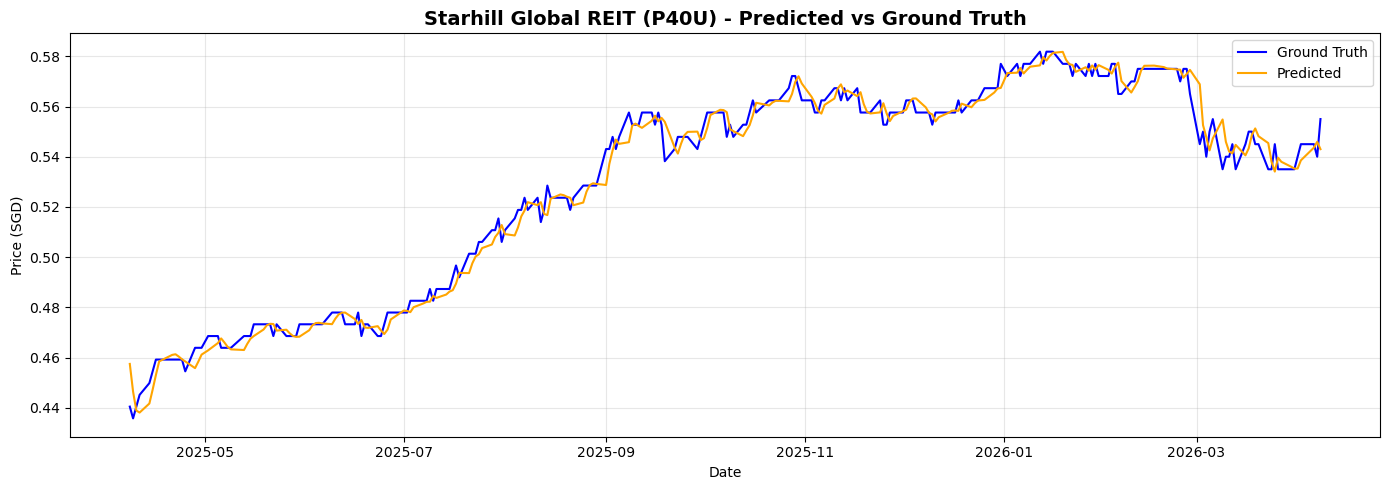

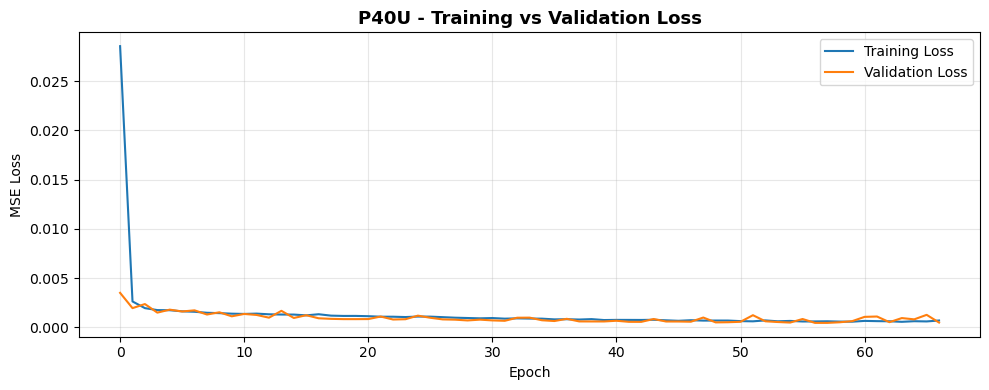

  Saved: ./results/P40U_result.pkl


In [4]:
# REIT 1/9: Starhill Global REIT
result_P40U = run_full_pipeline('P40U', REIT_UNIVERSE['P40U'])


  Frasers Centrepoint Trust (J69U)
  Sector: Retail

[1/7] Fetching price data...
  1322 rows (2021-01-04 to 2026-04-08)
[2/7] Loading sentiment data...
  No sentiment file for J69U
  No sentiment data - using neutral defaults
[3/7] Merging sentiment with price data...
[4/7] Scaling and creating sequences...
  Train: 1009 | Test: 253 | Features: 6
[5/7] Training LSTM model...
  Trained for 103 epochs
[6/7] Evaluating model...
  MAE:  0.015444
  MSE:  0.000361
  RMSE: 0.019004
  R2:   0.925399
[7/7] Simulating trading strategy (LSTM + sentiment + TA gate)...
  Net Profit:    SGD 2,930.92
  Net Return:    2.93%
  Buy & Hold:    6.45%
  Trades:        19
  TA flat days:  33.3% (EMA/RSI conflicted)


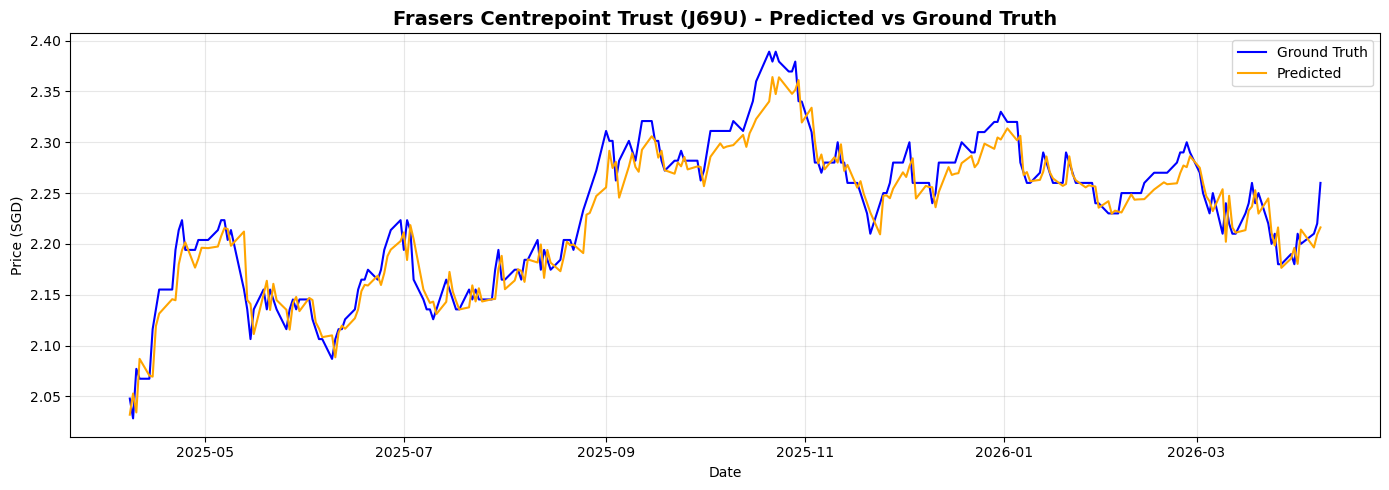

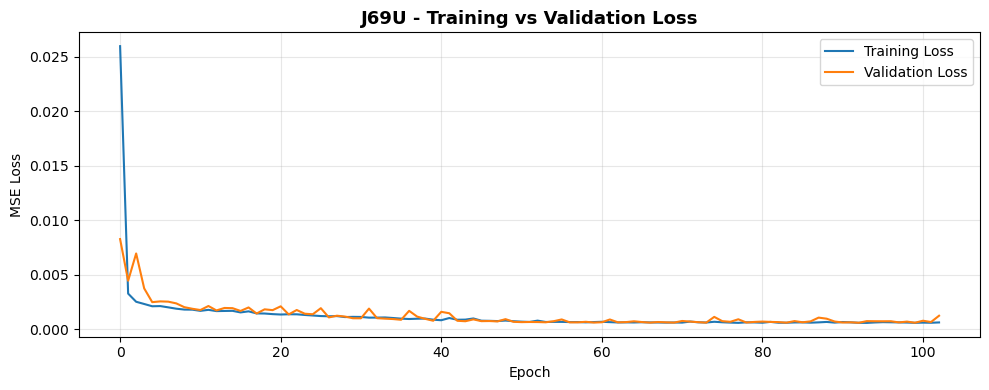

  Saved: ./results/J69U_result.pkl


In [5]:
# REIT 2/9: Frasers Centrepoint Trust
result_J69U = run_full_pipeline('J69U', REIT_UNIVERSE['J69U'])


  United Hampshire US REIT (ODBU)
  Sector: Retail

[1/7] Fetching price data...
  1322 rows (2021-01-04 to 2026-04-08)
[2/7] Loading sentiment data...
  No sentiment file for ODBU
  No sentiment data - using neutral defaults
[3/7] Merging sentiment with price data...
[4/7] Scaling and creating sequences...
  Train: 1009 | Test: 253 | Features: 6
[5/7] Training LSTM model...
  Trained for 112 epochs
[6/7] Evaluating model...
  MAE:  0.005268
  MSE:  0.000055
  RMSE: 0.007446
  R2:   0.968753
[7/7] Simulating trading strategy (LSTM + sentiment + TA gate)...
  Net Profit:    SGD 8,674.89
  Net Return:    8.67%
  Buy & Hold:    23.45%
  Trades:        14
  TA flat days:  22.4% (EMA/RSI conflicted)


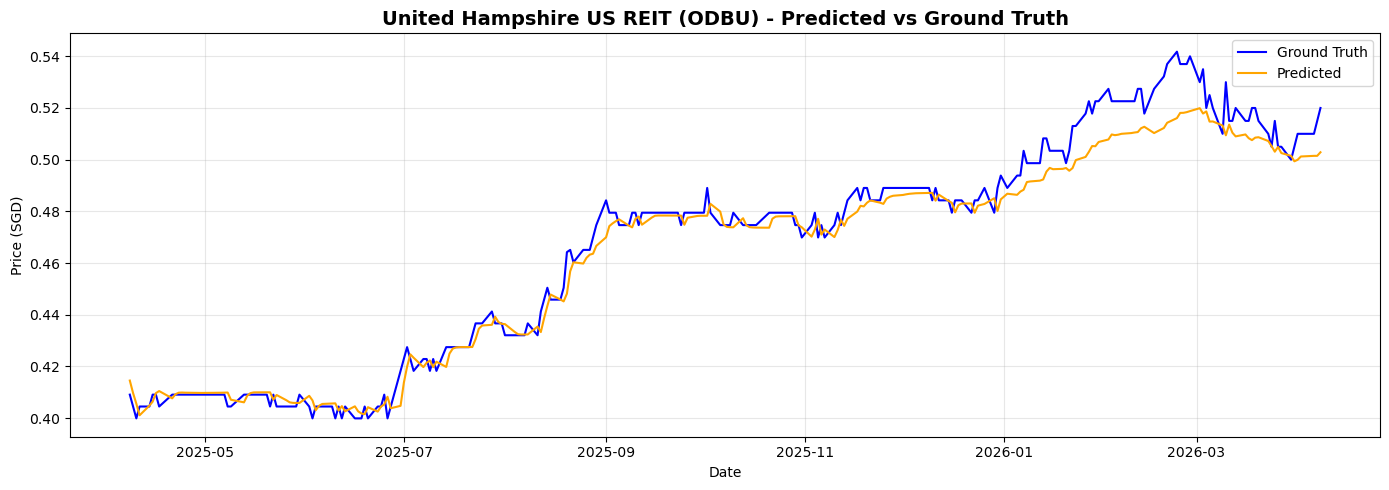

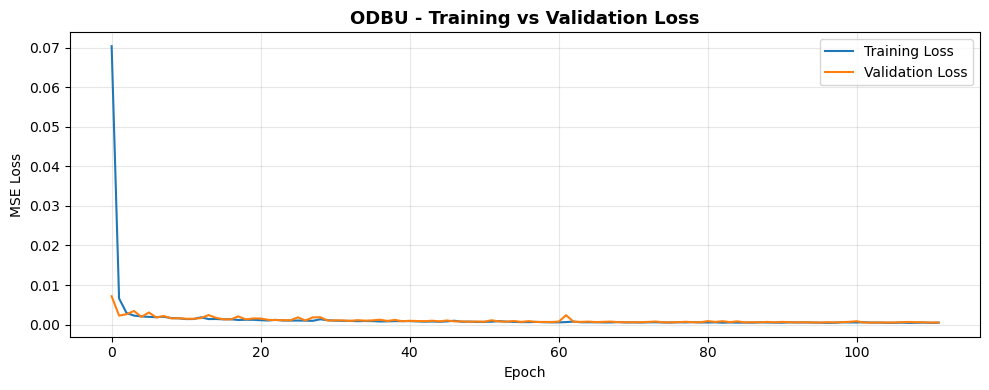

  Saved: ./results/ODBU_result.pkl


In [6]:
# REIT 3/9: United Hampshire US REIT
result_ODBU = run_full_pipeline('ODBU', REIT_UNIVERSE['ODBU'])


  Elite UK REIT (MXNU)
  Sector: Office

[1/7] Fetching price data...
  1322 rows (2021-01-04 to 2026-04-08)
[2/7] Loading sentiment data...
  No sentiment file for MXNU
  No sentiment data - using neutral defaults
[3/7] Merging sentiment with price data...
[4/7] Scaling and creating sequences...
  Train: 1009 | Test: 253 | Features: 6
[5/7] Training LSTM model...
  Trained for 12 epochs
[6/7] Evaluating model...
  MAE:  0.006824
  MSE:  0.000083
  RMSE: 0.009101
  R2:   0.888062
[7/7] Simulating trading strategy (LSTM + sentiment + TA gate)...
  Net Profit:    SGD 12,475.98
  Net Return:    12.48%
  Buy & Hold:    30.64%
  Trades:        7
  TA flat days:  23.2% (EMA/RSI conflicted)


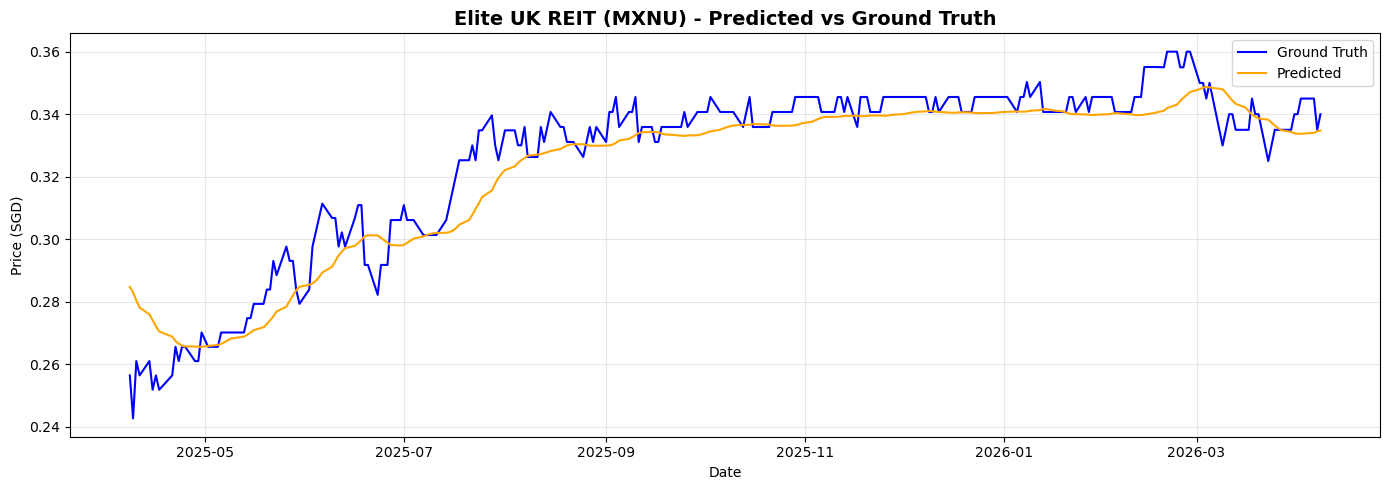

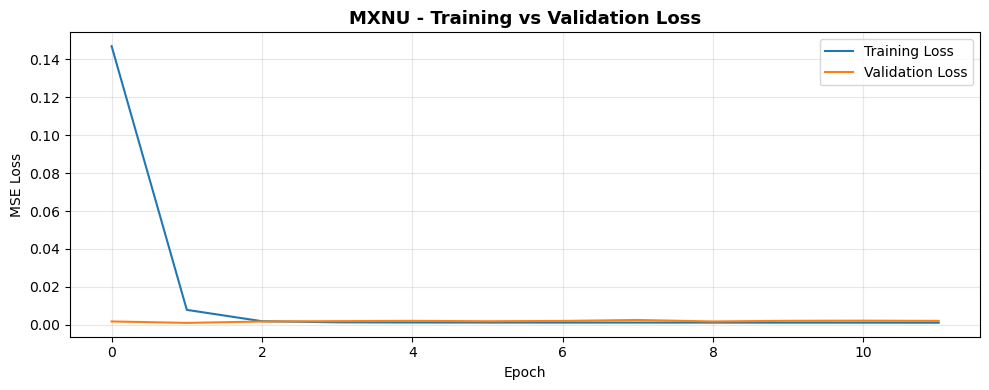

  Saved: ./results/MXNU_result.pkl


In [7]:
# REIT 4/9: Elite UK REIT
result_MXNU = run_full_pipeline('MXNU', REIT_UNIVERSE['MXNU'])


  Keppel REIT (K71U)
  Sector: Office

[1/7] Fetching price data...
  1322 rows (2021-01-04 to 2026-04-08)
[2/7] Loading sentiment data...
  No sentiment file for K71U
  No sentiment data - using neutral defaults
[3/7] Merging sentiment with price data...
[4/7] Scaling and creating sequences...
  Train: 1009 | Test: 253 | Features: 6
[5/7] Training LSTM model...
  Trained for 110 epochs
[6/7] Evaluating model...
  MAE:  0.008821
  MSE:  0.000145
  RMSE: 0.012024
  R2:   0.977641
[7/7] Simulating trading strategy (LSTM + sentiment + TA gate)...
  Net Profit:    SGD 11,414.86
  Net Return:    11.41%
  Buy & Hold:    15.50%
  Trades:        13
  TA flat days:  12.2% (EMA/RSI conflicted)


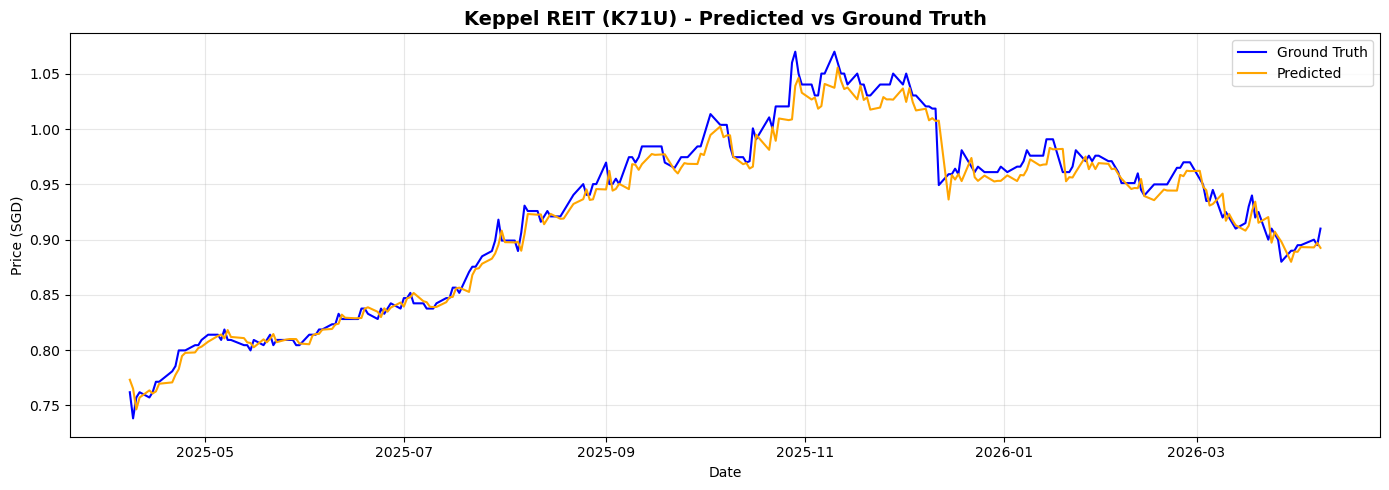

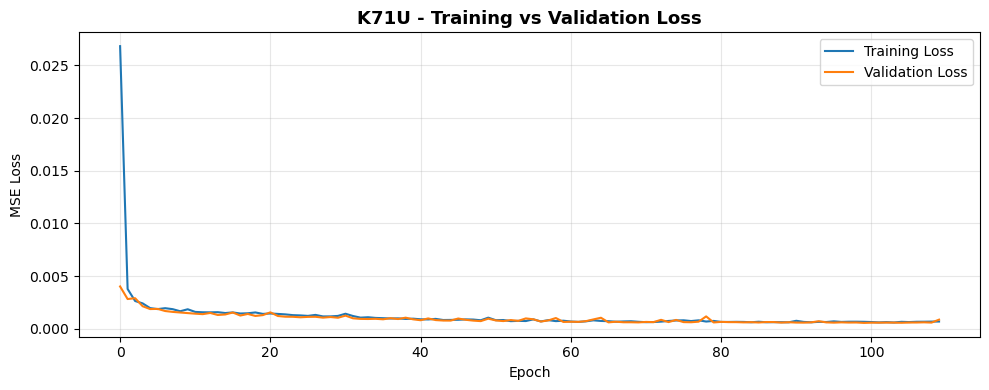

  Saved: ./results/K71U_result.pkl


In [8]:
# REIT 5/9: Keppel REIT
result_K71U = run_full_pipeline('K71U', REIT_UNIVERSE['K71U'])


  IREIT Global (UD1U)
  Sector: Office

[1/7] Fetching price data...
  1322 rows (2021-01-04 to 2026-04-08)
[2/7] Loading sentiment data...
  No sentiment file for UD1U
  No sentiment data - using neutral defaults
[3/7] Merging sentiment with price data...
[4/7] Scaling and creating sequences...
  Train: 1009 | Test: 253 | Features: 6
[5/7] Training LSTM model...
  Trained for 15 epochs
[6/7] Evaluating model...
  MAE:  0.008910
  MSE:  0.000170
  RMSE: 0.013038
  R2:   0.651114
[7/7] Simulating trading strategy (LSTM + sentiment + TA gate)...
  Net Profit:    SGD 5,589.83
  Net Return:    5.59%
  Buy & Hold:    6.29%
  Trades:        4
  TA flat days:  25.2% (EMA/RSI conflicted)


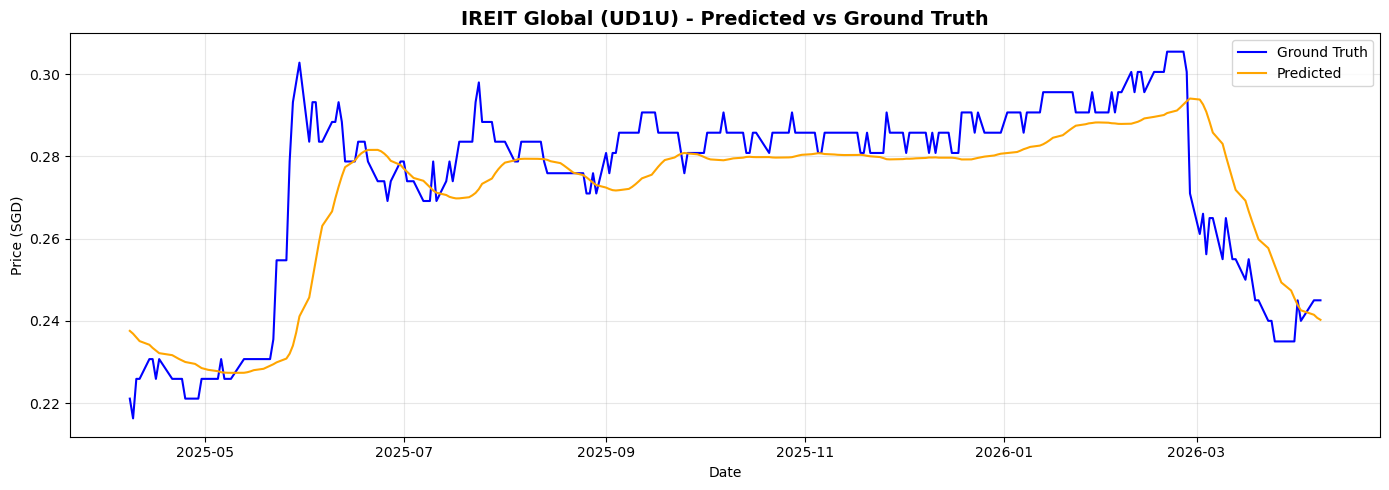

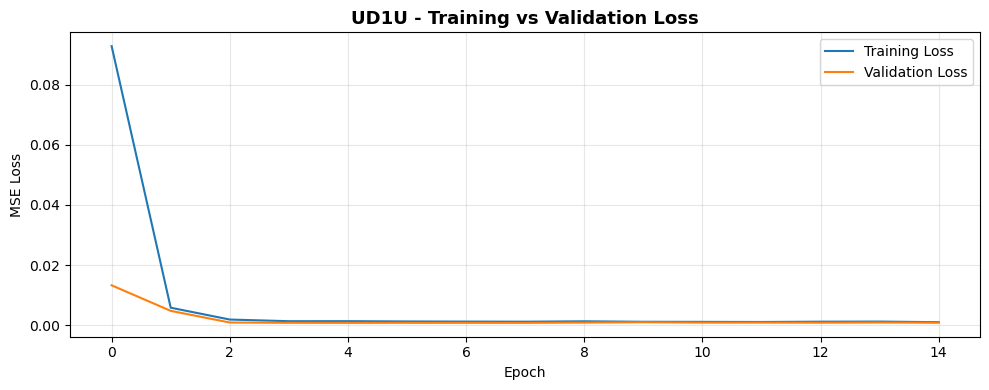

  Saved: ./results/UD1U_result.pkl


In [9]:
# REIT 6/9: IREIT Global
result_UD1U = run_full_pipeline('UD1U', REIT_UNIVERSE['UD1U'])


  CapitaLand Integrated Commercial Trust (C38U)
  Sector: Diversified

[1/7] Fetching price data...
  1322 rows (2021-01-04 to 2026-04-08)
[2/7] Loading sentiment data...
  No sentiment file for C38U
  No sentiment data - using neutral defaults
[3/7] Merging sentiment with price data...
[4/7] Scaling and creating sequences...
  Train: 1009 | Test: 253 | Features: 6
[5/7] Training LSTM model...
  Trained for 60 epochs
[6/7] Evaluating model...
  MAE:  0.019978
  MSE:  0.000657
  RMSE: 0.025632
  R2:   0.969525
[7/7] Simulating trading strategy (LSTM + sentiment + TA gate)...
  Net Profit:    SGD 11,024.98
  Net Return:    11.02%
  Buy & Hold:    19.70%
  Trades:        12
  TA flat days:  29.3% (EMA/RSI conflicted)


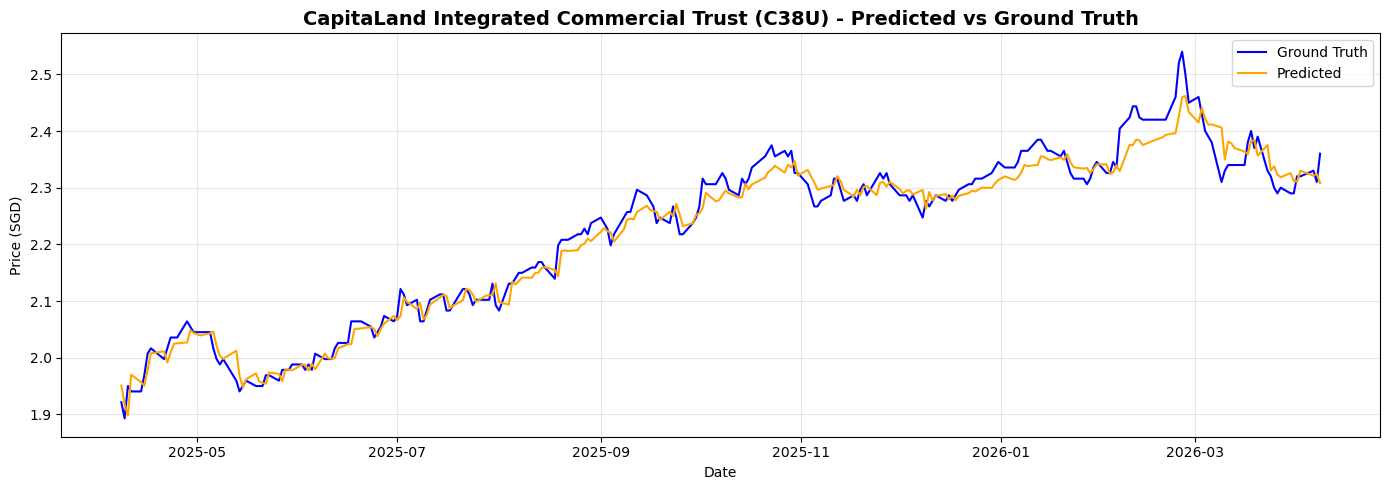

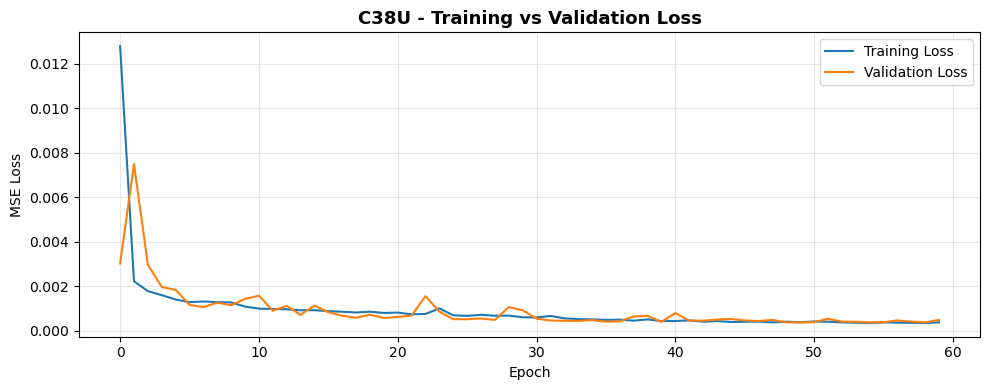

  Saved: ./results/C38U_result.pkl


In [10]:
# REIT 7/9: CapitaLand Integrated Commercial Trust
result_C38U = run_full_pipeline('C38U', REIT_UNIVERSE['C38U'])


  Frasers Logistics & Commercial Trust (BUOU)
  Sector: Diversified

[1/7] Fetching price data...
  1322 rows (2021-01-04 to 2026-04-08)
[2/7] Loading sentiment data...
  No sentiment file for BUOU
  No sentiment data - using neutral defaults
[3/7] Merging sentiment with price data...
[4/7] Scaling and creating sequences...
  Train: 1009 | Test: 253 | Features: 6
[5/7] Training LSTM model...
  Trained for 109 epochs
[6/7] Evaluating model...
  MAE:  0.009609
  MSE:  0.000177
  RMSE: 0.013287
  R2:   0.972537
[7/7] Simulating trading strategy (LSTM + sentiment + TA gate)...
  Net Profit:    SGD 18,667.69
  Net Return:    18.67%
  Buy & Hold:    14.69%
  Trades:        14
  TA flat days:  24.0% (EMA/RSI conflicted)


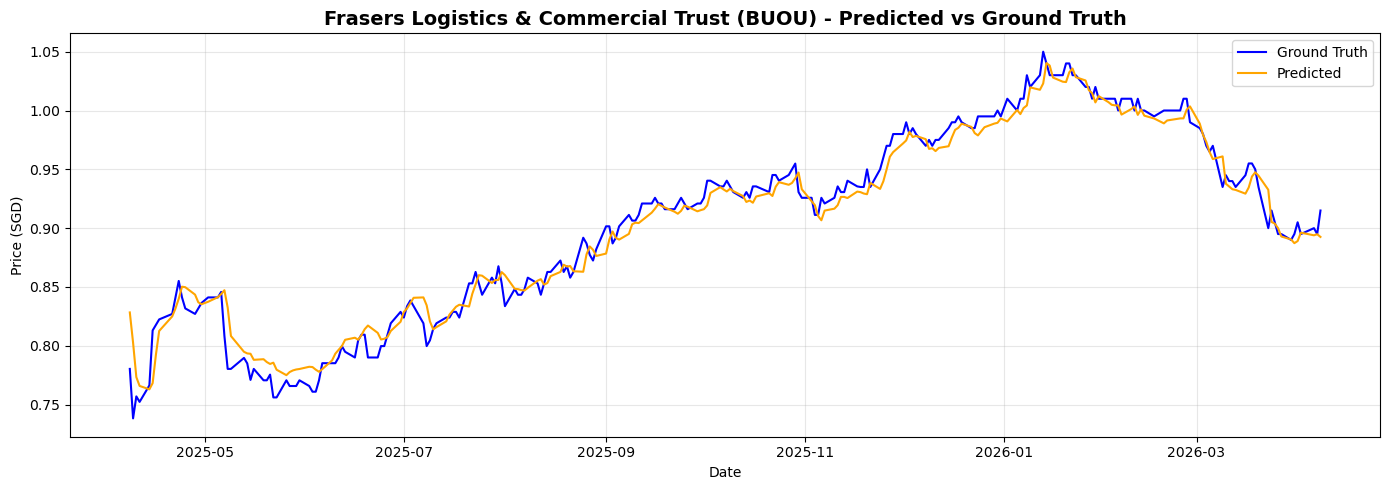

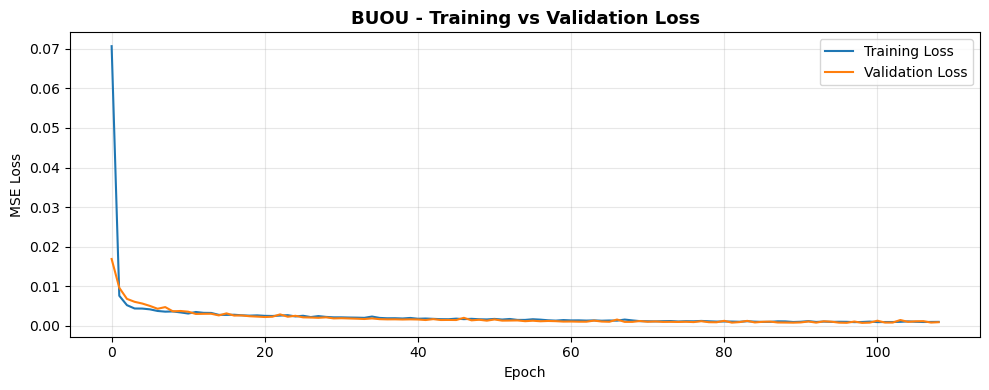

  Saved: ./results/BUOU_result.pkl


In [11]:
# REIT 8/9: Frasers Logistics & Commercial Trust
result_BUOU = run_full_pipeline('BUOU', REIT_UNIVERSE['BUOU'])


  OUE REIT (TS0U)
  Sector: Diversified

[1/7] Fetching price data...
  1322 rows (2021-01-04 to 2026-04-08)
[2/7] Loading sentiment data...
  No sentiment file for TS0U
  No sentiment data - using neutral defaults
[3/7] Merging sentiment with price data...
[4/7] Scaling and creating sequences...
  Train: 1009 | Test: 253 | Features: 6
[5/7] Training LSTM model...
  Trained for 138 epochs
[6/7] Evaluating model...
  MAE:  0.003761
  MSE:  0.000025
  RMSE: 0.005012
  R2:   0.981139
[7/7] Simulating trading strategy (LSTM + sentiment + TA gate)...
  Net Profit:    SGD 18,514.21
  Net Return:    18.51%
  Buy & Hold:    45.86%
  Trades:        19
  TA flat days:  19.5% (EMA/RSI conflicted)


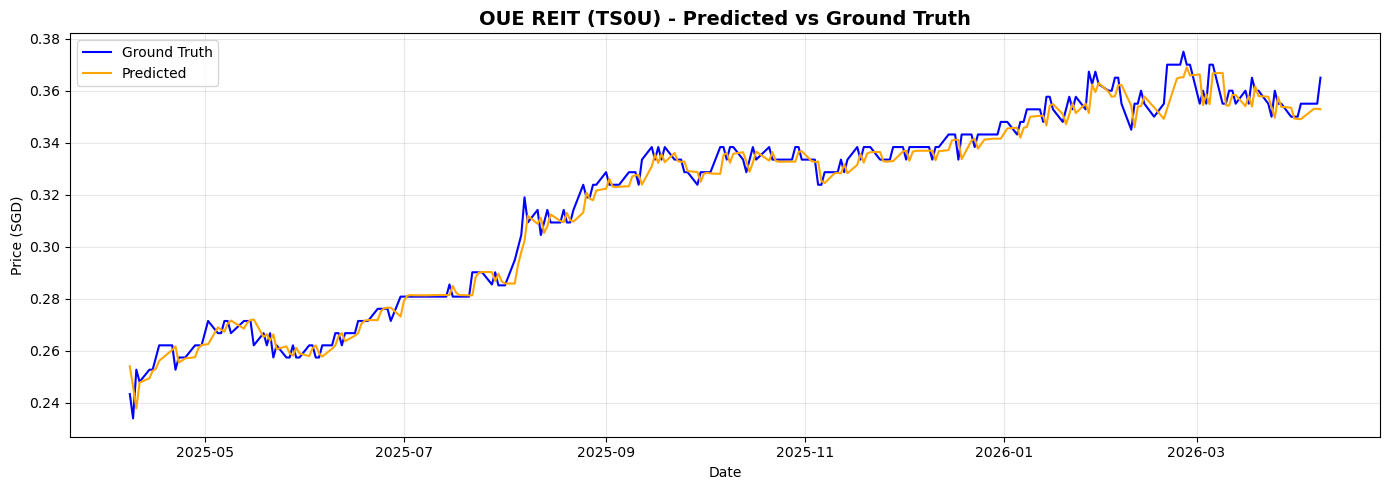

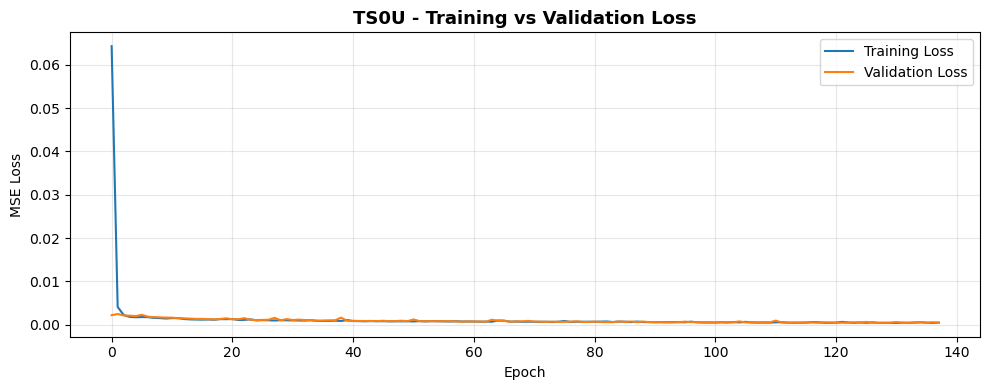

  Saved: ./results/TS0U_result.pkl


In [12]:
# REIT 9/9: OUE REIT
result_TS0U = run_full_pipeline('TS0U', REIT_UNIVERSE['TS0U'])

## Compile Results & Benchmark

In [13]:
# COMPILATION OF ALL RESULTS 


all_results = {}
for ticker in TICKERS:
    pkl_path = f'{RESULTS_DIR}/{ticker}_result.pkl'
    if os.path.exists(pkl_path):
        with open(pkl_path, 'rb') as f:
            all_results[ticker] = pickle.load(f)
        print(f'  Loaded: {ticker}')
    else:
        print(f'  Missing: {ticker}')

print(f'\nLoaded {len(all_results)}/9 REITs')

  Loaded: P40U
  Loaded: J69U
  Loaded: ODBU
  Loaded: MXNU
  Loaded: K71U
  Loaded: UD1U
  Loaded: C38U
  Loaded: BUOU
  Loaded: TS0U

Loaded 9/9 REITs


In [14]:
# SRT.SI BENCHMARK (fixed from TradingView, 2023-03-27 to 2026-03-27)

CLR_RETURN_FIXED = 4.36   # iEdge S-REIT Leaders Index total return (%)
clr_return = CLR_RETURN_FIXED
print(f'SRT.SI benchmark return (fixed): {clr_return:.2f}%')

SRT.SI return (2023-03-27 to 2026-03-27): 0.73%


In [15]:

# SUMMARY TABLE - Net Profit of Each Strategy

rows = []
total_profit  = 0
total_capital = 0

for ticker in TICKERS:
    if ticker not in all_results:
        continue
    r = all_results[ticker]
    s = r['strategy']
    m = r['metrics']

    rows.append({
        'Ticker':           ticker,
        'Name':             r['name'],
        'Sector':           r['sector'],
        'MAE':              m['MAE'],
        'MSE':              m['MSE'],
        'RMSE':             m['RMSE'],
        'R2':               m['R2'],
        'Net Profit (SGD)': s['net_profit'],
        'Net Return (%)':   s['net_return'],
        'Trades':           s['n_trades'],
        'TA Flat (%)':      s.get('ta_conflict_pct', float('nan')),
    })
    total_profit  += s['net_profit']
    total_capital += INITIAL_CAPITAL

summary_df = pd.DataFrame(rows)

total_return = (total_profit / total_capital) * 100 if total_capital > 0 else 0
print(f'\n{"="*80}')
print(f'  NEWS-DRIVEN LSTM NEXT-DAY PREDICTIVE TRADING STRATEGY')
print(f'  TA Confirmation Gate: EMA({EMA_FAST}/{EMA_SLOW}) + RSI({RSI_PERIOD})')
print(f'  Period: {TRADE_START} to {TRADE_END}')
print(f'  Capital: SGD {INITIAL_CAPITAL:,} per REIT | Total: SGD {total_capital:,}')
print(f'{"="*80}')

display_df = summary_df.copy()
display_df['Net Profit (SGD)'] = display_df['Net Profit (SGD)'].map('{:,.2f}'.format)
display_df['Net Return (%)']   = display_df['Net Return (%)'].map('{:.2f}'.format)
display_df['MAE']              = display_df['MAE'].map('{:.6f}'.format)
display_df['MSE']              = display_df['MSE'].map('{:.6f}'.format)
display_df['RMSE']             = display_df['RMSE'].map('{:.6f}'.format)
display_df['R2']               = display_df['R2'].map('{:.6f}'.format)
display_df['TA Flat (%)']      = display_df['TA Flat (%)'].map('{:.1f}'.format)
print(display_df.to_string(index=False))

print(f'\n  Total Net Profit:  SGD {total_profit:,.2f}')
print(f'  Total Net Return:  {total_return:.2f}%')
print(f'  SRT.SI Return:     {clr_return:.2f}%')
print(f'  Outperformance:    {total_return - clr_return:+.2f}%')

summary_df.to_csv(f'{RESULTS_DIR}/strategy_summary.csv', index=False)
print(f'\n  Saved: {RESULTS_DIR}/strategy_summary.csv')



  NEWS-DRIVEN LSTM NEXT-DAY PREDICTIVE TRADING STRATEGY
  TA Confirmation Gate: EMA(20/50) + RSI(14)
  Period: 2023-03-27 to 2026-03-27
  Capital: SGD 100,000 per REIT | Total: SGD 900,000
Ticker                                   Name      Sector      MAE      MSE     RMSE       R2 Net Profit (SGD) Net Return (%) Buy & Hold (%)  Trades TA Flat (%)
  P40U                   Starhill Global REIT      Retail 0.003691 0.000025 0.005020 0.984865        13,921.25          13.92          21.47      40        19.1
  J69U              Frasers Centrepoint Trust      Retail 0.015444 0.000361 0.019004 0.925399         2,930.92           2.93           6.45      19        33.3
  ODBU               United Hampshire US REIT      Retail 0.005268 0.000055 0.007446 0.968753         8,674.89           8.67          23.45      14        22.4
  MXNU                          Elite UK REIT      Office 0.006824 0.000083 0.009101 0.888062        12,475.98          12.48          30.64       7        23.2
  K71

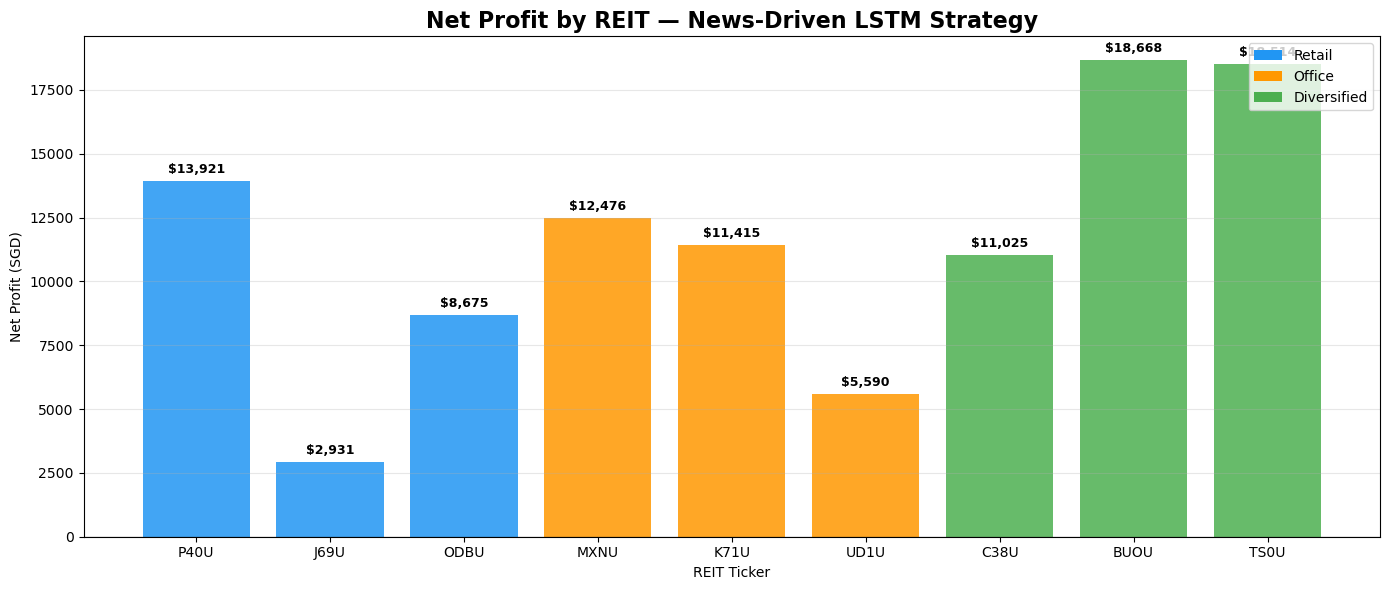

In [16]:
# CHART: Net Profit by REIT

fig, ax = plt.subplots(figsize=(14, 6))

sector_colors = {'Retail': '#2196F3', 'Office': '#FF9800', 'Diversified': '#4CAF50'}
colors = [sector_colors.get(all_results[t]['sector'], 'gray') for t in summary_df['Ticker']]

bars = ax.bar(summary_df['Ticker'], summary_df['Net Profit (SGD)'], color=colors, alpha=0.85)
ax.axhline(y=0, color='black', lw=0.8)

# Value labels
for bar in bars:
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, v + (200 if v >= 0 else -500),
            f'${v:,.0f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=9, fontweight='bold')

ax.set_title('Net Profit by REIT — News-Driven LSTM Strategy', fontsize=16, fontweight='bold')
ax.set_ylabel('Net Profit (SGD)'); ax.set_xlabel('REIT Ticker')
ax.grid(True, axis='y', alpha=0.3)
ax.legend(handles=[Patch(facecolor=c, label=s) for s, c in sector_colors.items()], loc='upper right')
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/net_profit_by_reit.png', dpi=150, bbox_inches='tight')
plt.show()

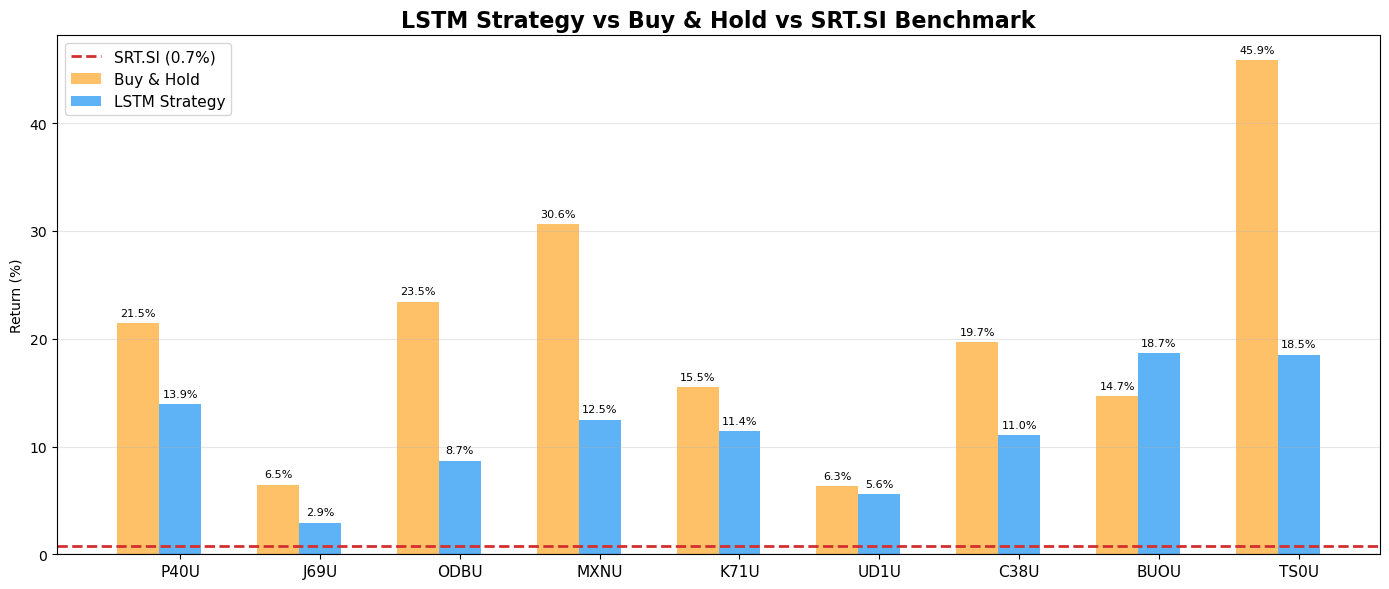

In [17]:
# ============================================================
# CHART: Strategy Return vs SRT.SI
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(summary_df))
w = 0.5

b1 = ax.bar(x, summary_df['Net Return (%)'], w, label='LSTM Strategy', color='#42A5F5', alpha=0.85)

# SRT.SI benchmark line (fixed at 4.36% from TradingView)
ax.axhline(y=clr_return, color='#D32F2F', ls='--', lw=2, label=f'SRT.SI Benchmark ({clr_return:.2f}%)')
ax.axhline(y=0, color='black', lw=0.8)

ax.set_xticks(x); ax.set_xticklabels(summary_df['Ticker'], fontsize=11)
ax.set_ylabel('Return (%)')
ax.set_title('LSTM Strategy Return vs iEdge S-REIT Leaders Index (SRT.SI)', fontsize=16, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True, axis='y', alpha=0.3)

for bar in b1:
    v = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, v + (0.3 if v >= 0 else -0.6),
            f'{v:.1f}%', ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/strategy_vs_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()


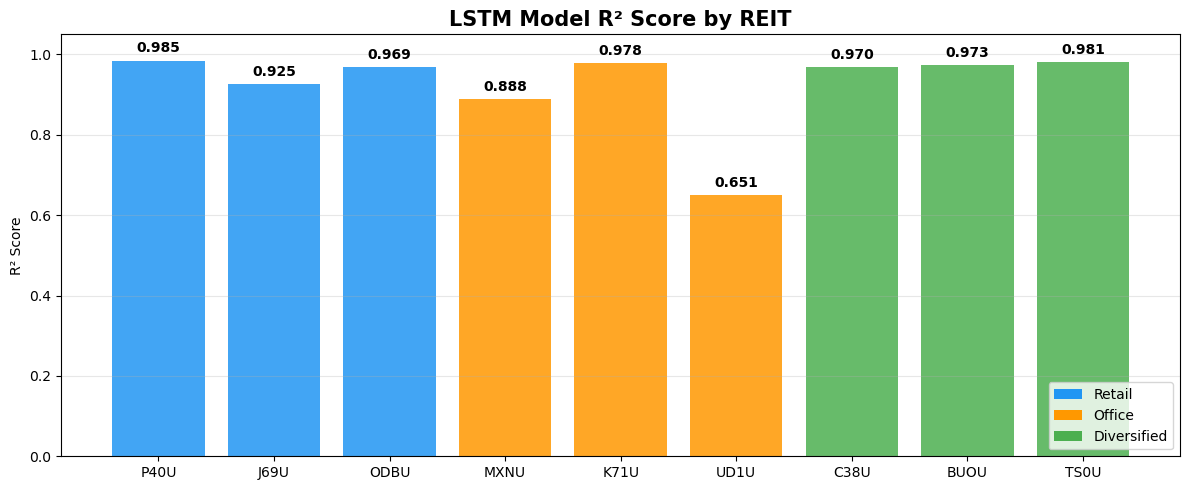

In [20]:
# Model Accuracy (R²) by REIT Chart

fig, ax = plt.subplots(figsize=(12, 5))
colors = [sector_colors.get(all_results[t]['sector'], 'gray') for t in summary_df['Ticker']]
ax.bar(summary_df['Ticker'], summary_df['R2'], color=colors, alpha=0.85)
ax.set_title('LSTM Model R² Score by REIT', fontsize=15, fontweight='bold')
ax.set_ylabel('R² Score'); ax.set_ylim(0, 1.05)
ax.grid(True, axis='y', alpha=0.3)
ax.legend(handles=[Patch(facecolor=c, label=s) for s, c in sector_colors.items()], loc='lower right')

for i, v in enumerate(summary_df['R2']):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/r2_by_reit.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# LIST ALL SAVED FILES

print(f'\nAll output files in {RESULTS_DIR}/:')
for f in sorted(os.listdir(RESULTS_DIR)):
    size = os.path.getsize(os.path.join(RESULTS_DIR, f))
    print(f'  {f} ({size/1024:.0f} KB)')


All output files in ./results/:
  BUOU_prediction.png (121 KB)
  BUOU_result.pkl (19 KB)
  BUOU_training_loss.png (51 KB)
  C38U_prediction.png (116 KB)
  C38U_result.pkl (19 KB)
  C38U_training_loss.png (59 KB)
  J69U_prediction.png (138 KB)
  J69U_result.pkl (19 KB)
  J69U_training_loss.png (54 KB)
  K71U_prediction.png (112 KB)
  K71U_result.pkl (19 KB)
  K71U_training_loss.png (50 KB)
  MXNU_prediction.png (100 KB)
  MXNU_result.pkl (18 KB)
  MXNU_training_loss.png (45 KB)
  ODBU_prediction.png (106 KB)
  ODBU_result.pkl (19 KB)
  ODBU_training_loss.png (50 KB)
  P40U_prediction.png (112 KB)
  P40U_result.pkl (21 KB)
  P40U_training_loss.png (51 KB)
  TS0U_prediction.png (112 KB)
  TS0U_result.pkl (19 KB)
  TS0U_training_loss.png (48 KB)
  UD1U_prediction.png (102 KB)
  UD1U_result.pkl (18 KB)
  UD1U_training_loss.png (43 KB)
  mse_vs_profit.png (72 KB)
  net_profit_by_reit.png (72 KB)
  r2_by_reit.png (51 KB)
  strategy_summary.csv (2 KB)
  strategy_vs_benchmark.png (78 KB)


## Output Summary

**Per-REIT files:**
- `{TICKER}_result.pkl` — Full results (predictions, trades, metrics)
- `{TICKER}_prediction.png` — Predicted vs Ground Truth chart
- `{TICKER}_training_loss.png` — Training vs validation loss

**Portfolio files:**
- `strategy_summary.csv` — All metrics and returns in one table
- `net_profit_by_reit.png` — Bar chart of net profits per REIT
- `strategy_vs_benchmark.png` — LSTM Strategy vs SRT.SI benchmark
- `r2_by_reit.png` — Model R² accuracy by REIT
